In [8]:
# Sparse linear regression experiment

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# Problem setup
n, d, s = 2000, 100, 10
noise_std = 0.1
epochs = 50
batch_size = 50

# Generate data
X = np.random.randn(n, d)
w_star = np.zeros(d)
support = np.random.choice(d, s, replace=False)
w_star[support] = np.random.randn(s)
y = X @ w_star + noise_std * np.random.randn(n)

# Helpers
def mse_loss(w):
    r = X @ w - y
    return 0.5 * np.mean(r**2)

def grad_batch(w, idx):
    Xb = X[idx]
    yb = y[idx]
    r = Xb @ w - yb
    return Xb.T @ r / len(idx)

def run_sgd(lr):
    w = np.zeros(d)
    losses, dists = [], []
    for ep in range(epochs):
        perm = np.random.permutation(n)
        for i in range(0, n, batch_size):
            idx = perm[i:i+batch_size]
            g = grad_batch(w, idx)
            w -= lr * g
        losses.append(mse_loss(w))
        dists.append(np.linalg.norm(w - w_star))
    return np.array(losses), np.array(dists)

def run_adagrad_diag(lr, eps=1e-8):
    w = np.zeros(d)
    G = np.zeros(d)
    losses, dists = [], []
    for ep in range(epochs):
        perm = np.random.permutation(n)
        for i in range(0, n, batch_size):
            idx = perm[i:i+batch_size]
            g = grad_batch(w, idx)
            G += g**2
            w -= lr * g / (np.sqrt(G) + eps)
        losses.append(mse_loss(w))
        dists.append(np.linalg.norm(w - w_star))
    return np.array(losses), np.array(dists)

def run_adagrad_norm(lr, eps=1e-8):
    w = np.zeros(d)
    Gn = 0.0
    losses, dists = [], []
    for ep in range(epochs):
        perm = np.random.permutation(n)
        for i in range(0, n, batch_size):
            idx = perm[i:i+batch_size]
            g = grad_batch(w, idx)
            Gn += np.linalg.norm(g)**2
            w -= lr * g / (np.sqrt(Gn) + eps)
        losses.append(mse_loss(w))
        dists.append(np.linalg.norm(w - w_star))
    return np.array(losses), np.array(dists)

# Learning rate grids
lrs_sgd = [0.005, 0.01, 0.05, 0.1, 0.2]
lrs_ada = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0]

results = {}

# SGD
best = None
for lr in lrs_sgd:
    losses, dists = run_sgd(lr)
    final = losses[-1]
    if best is None or final < best[0]:
        best = (final, lr, losses, dists)
results["SGD"] = best

# AdaGrad diag
best = None
for lr in lrs_ada:
    losses, dists = run_adagrad_diag(lr)
    final = losses[-1]
    if best is None or final < best[0]:
        best = (final, lr, losses, dists)
results["AdaGrad (diag)"] = best

# AdaGrad norm
best = None
for lr in lrs_ada:
    losses, dists = run_adagrad_norm(lr)
    final = losses[-1]
    if best is None or final < best[0]:
        best = (final, lr, losses, dists)
results["AdaGrad-Norm"] = best

results


{'SGD': (np.float64(0.00451539144550499),
  0.01,
  array([1.85030138, 0.84078642, 0.39514817, 0.19206432, 0.09679925,
         0.05089245, 0.02828686, 0.01689941, 0.01107311, 0.00802951,
         0.00641565, 0.00555462, 0.00509168, 0.00483677, 0.00469706,
         0.0046185 , 0.00457375, 0.00454843, 0.0045345 , 0.00452672,
         0.00452193, 0.00451921, 0.00451738, 0.00451648, 0.00451621,
         0.00451564, 0.00451538, 0.00451541, 0.00451542, 0.00451523,
         0.00451539, 0.0045153 , 0.00451532, 0.00451552, 0.00451558,
         0.00451547, 0.00451542, 0.00451553, 0.00451553, 0.00451542,
         0.00451524, 0.00451551, 0.00451554, 0.00451565, 0.00451534,
         0.00451548, 0.00451551, 0.00451532, 0.00451528, 0.00451539]),
  array([1.97952067, 1.36012548, 0.9482902 , 0.66991606, 0.47899564,
         0.34631944, 0.25330058, 0.18726186, 0.1402552 , 0.10649745,
         0.08214015, 0.06477574, 0.05247966, 0.04369346, 0.03767884,
         0.03346184, 0.03045938, 0.02861214, 0.0273

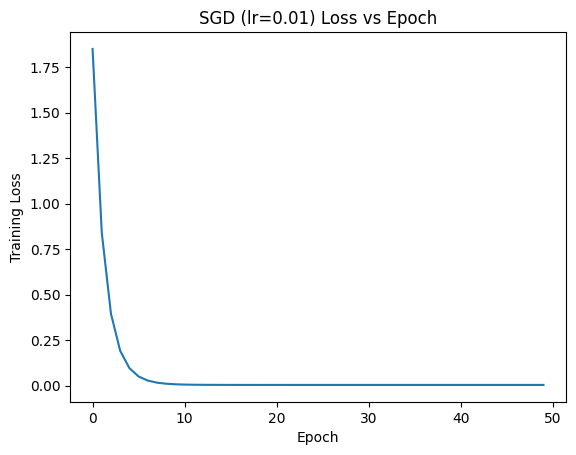

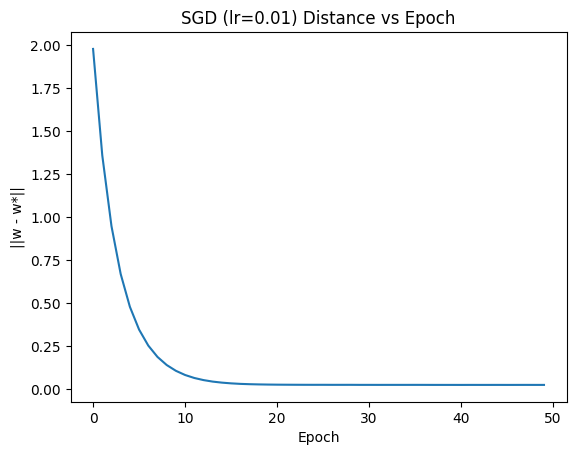

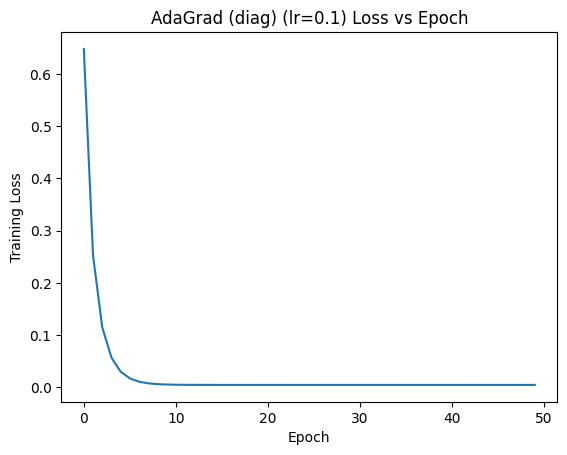

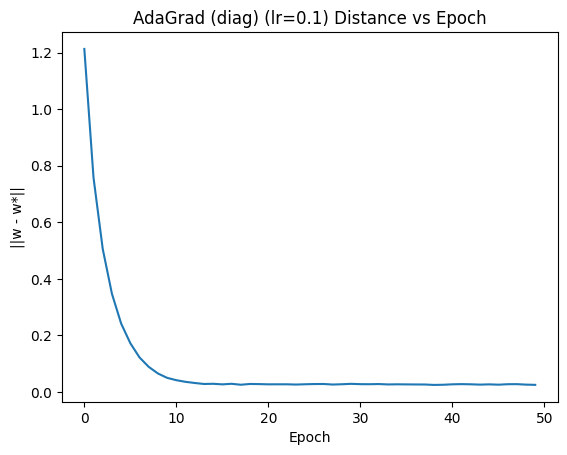

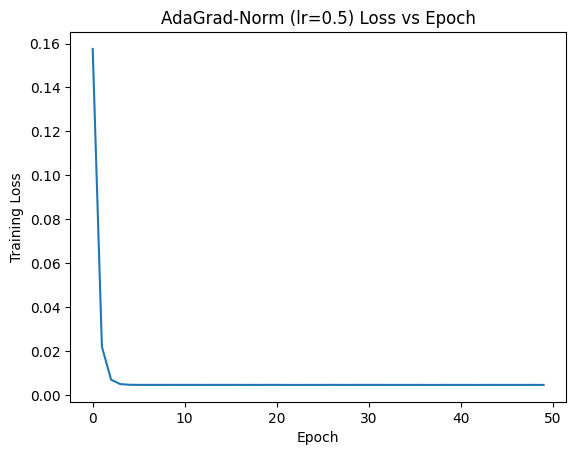

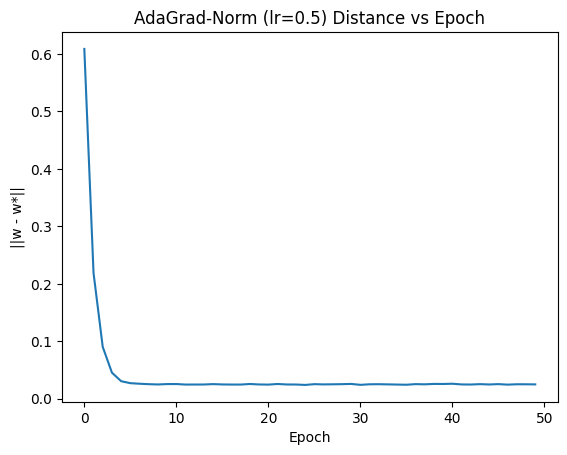

In [9]:
# Plotting for best learning rate of each optimizer

for name, (final, lr, losses, dists) in results.items():
    # Loss plot
    plt.figure()
    plt.plot(losses)
    plt.xlabel("Epoch")
    plt.ylabel("Training Loss")
    plt.title(f"{name} (lr={lr}) Loss vs Epoch")
    plt.show()

    # Distance plot
    plt.figure()
    plt.plot(dists)
    plt.xlabel("Epoch")
    plt.ylabel("||w - w*||")
    plt.title(f"{name} (lr={lr}) Distance vs Epoch")
    plt.show()


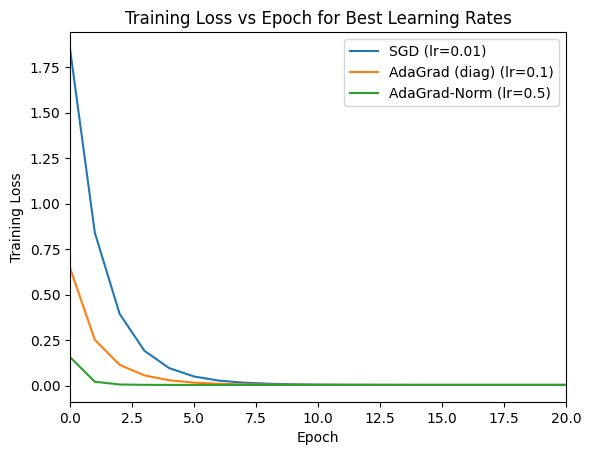

In [10]:
# superimpose each of the 3 plots over eachother for better comparison
plt.figure()
for name, (final, lr, losses, dists) in results.items():
    plt.plot(losses, label=f"{name} (lr={lr})")
plt.xlabel("Epoch")
plt.xlim(0, 20)
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epoch for Best Learning Rates")
plt.legend()
plt.show()


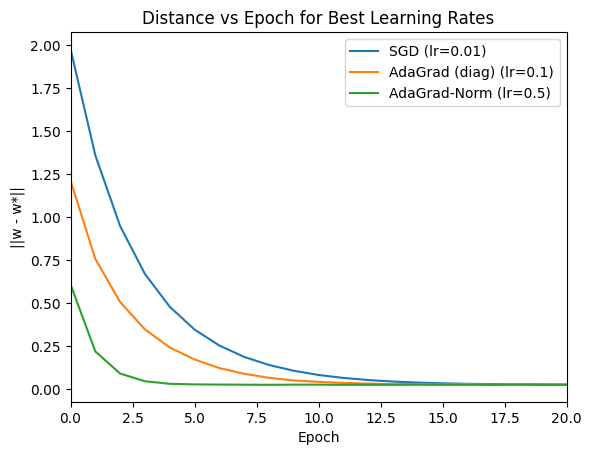

In [11]:
# superimpose each of the 3 plots over eachother for better comparison
plt.figure()
for name, (final, lr, losses, dists) in results.items():
    plt.plot(dists, label=f"{name} (lr={lr})")
plt.xlabel("Epoch")
plt.xlim(0, 20)
plt.ylabel("||w - w*||")
plt.title("Distance vs Epoch for Best Learning Rates")
plt.legend()
plt.show()